<a href="https://colab.research.google.com/github/e23189uop/Statistical-Learning-e23189/blob/main/assignment%2301_e23189/fundamentals_of_probability_assignment01_e23189.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


### Answer :

Let the disk be

$$\Omega=\{(x,y)\in \mathbb{R}^2 : x^2+y^2\le 10^2\}.$$


Let $A$ be the event that the chosen point lies within $1$ unit of the boundary. Since the boundary is the circle of radius $10$, this means the point has distance at least $9$ from the center and at most $10$. Thus

$$A=\left\{(x,y)\in \Omega : 9\le \sqrt{x^2+y^2}\le 10\right\}.$$

So $A$ is the outer annulus of the disk.

---

**1. Uniform Distribution with Respect to Area**

If the point is uniformly distributed with respect to the area, the probability is the ratio of the area of the region defining event $A$ to the total area of the disk.

*   Total area of the disk: $A_{\text{total}} = \pi \cdot 10^2 = 100\pi$
*   Area of event $A$: The area within $1$ unit of the boundary is an annulus. $A_{\text{event}} = 100\pi - 81\pi = 19\pi$.

<center>$\boxed{P(A) = \frac{19\pi}{100\pi} = \frac{19}{100} = 0.19}$</center>
</p>

---

**2. Uniform Distribution with Respect to Distance from Center**

In this model, we have two independent variables: Radius ($r$), and Angle ($\theta$).

Event $A$ occurs if the point is within $1$ unit of the boundary, which means the distance $r$ must fall in the interval $[9, 10]$.

However, the choice of angle $\theta$ is independent of the radius, and the direction does not affect the probability of falling within a certain distance from the center.

Since $r$ is uniformly distributed over a segment of length $10$, the probability is the length of the **successful interval** divided by the **total interval** length.


<center>$\boxed{P(A) = \frac{10 - 9}{10 - 0} = \frac{1}{10} = 0.10}$</center>
</p>

---

**3. Why the Two Answers Differ**

The answers differ because the two models define the concept of a "randomly chosen point" differently:

* **Model 1 (Uniform Area):** The probability density is constant across the 2D surface of the disk. Because the area of a circle scales with the square of the radius ($r^2$), there is exponentially more space at the outer edges of a disk than near the center. Thus, a point is more likely to fall near the boundary.

* **Model 2 (Uniform Radius):** Forcing the distance to be uniformly distributed ignores the 2D geometry of the disk. It spreads the points out evenly along a 1D line from the center to the edge. When mapped back to the 2D disk, this creates a high density of points clustered near the center and a sparse density near the edges, significantly lowering the probability of landing in the outer ring.



# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

### Answer :

Let the circle have radius $R$.

The side length $L$ of an inscribed equilateral triangle is

$$L = \sqrt{3}R $$

A chord is longer than $L$ if it is closer to the center of the circle than the sides of the triangle, which sit at a distance of $R/2$ from the center.

**PROOF:**

We want chord length $l$ such that,
$$
l > L
$$

Let $r$ be the perpendicular distance from the Chord to the center. Then, using pythagoras theorem,

$$
2\sqrt{R^2 - r^2} > \sqrt{3}R
$$

$$
4R^2 - 4r^2 > 3R^2
$$

$$
R^2 > 4r^2
$$


$$\boxed{
r < \frac R 2
}$$

**Model-1: Random Endpoints**

* **Method:** Choose two random points uniformly on the circumference of the circle and draw a chord between them.
* **Calculation:** Fix the first point. For the chord to be longer than the side of the inscribed equilateral triangle, the second point must fall on the arc of the circle opposite the first point. The inscribed equilateral triangle divides the circumference into three equal arcs of $120^\circ$ (or $2\pi/3$ radians).
* **Result:** The second point must land in the middle $1/3$ of the circle's circumference.


* **Probability =** $\frac13$


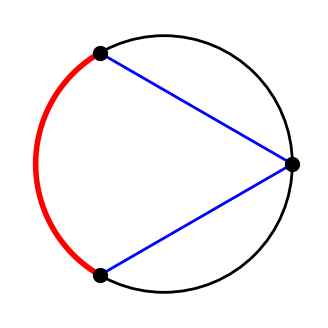

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axis
fig, ax = plt.subplots(figsize=(4, 4))

# 1. Define the 3 points (0, 120, and 240 degrees in radians)
theta1 = 0
theta2 = 2 * np.pi / 3
theta3 = 4 * np.pi / 3

x_points = [np.cos(theta1), np.cos(theta2), np.cos(theta3)]
y_points = [np.sin(theta1), np.sin(theta2), np.sin(theta3)]

# 2. Generate points for the red arc (from 120 to 240 degrees)
arc_thetas = np.linspace(theta2, theta3, 100)
arc_x = np.cos(arc_thetas)
arc_y = np.sin(arc_thetas)

# 3. Draw the black circle
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
ax.add_artist(circle)

# 4. Draw the red arc
ax.plot(arc_x, arc_y, color='red', linewidth=4, zorder=3)

# 5. Draw the 2 chords from Dot 1 to Dot 2 and Dot 1 to Dot 3
ax.plot([x_points[0], x_points[1]], [y_points[0], y_points[1]], color='blue', linewidth=2)
ax.plot([x_points[0], x_points[2]], [y_points[0], y_points[2]], color='blue', linewidth=2)

# 6. Plot the 3 dots
ax.scatter(x_points, y_points, color='black', s=100, zorder=5)

# Formatting
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
plt.axis('off')

plt.show()

**Model-2: Random Radius (Random Radial Point)**
* **Method:** Choose a random radius of the circle, and choose a point uniformly along that radius. Draw the chord perpendicular to the radius at that point.
* **Calculation:** The sides of an inscribed equilateral triangle bisect the radii they intersect. Therefore, the distance from the center to any side of the triangle is exactly $R/2$. For the randomly chosen perpendicular chord to be longer than the triangle's side, its midpoint must be closer to the center than $R/2$.
* **Result:** The chosen point on the radius must fall uniformly between $0$ and $R/2$, which is exactly half the length of the radius $[0, R]$.

* **Probability =** $\frac12$

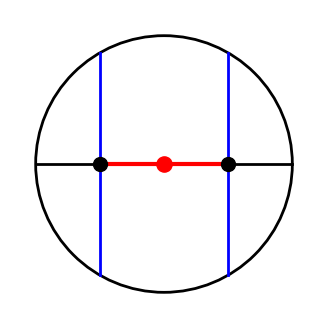

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(4, 4))

# Define constants
radius = 1.0
x_mid_left = -0.5
x_mid_right = 0.5
y_limit = np.sqrt(radius**2 - x_mid_right**2)

# 1. Draw the black circle
circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=2)
ax.add_artist(circle)

# 2. Draw the diameter (Black outer segments, Red middle segment)
ax.plot([-1, x_mid_left], [0, 0], color='black', linewidth=2)
ax.plot([x_mid_right, 1], [0, 0], color='black', linewidth=2)
ax.plot([x_mid_left, x_mid_right], [0, 0], color='red', linewidth=3)

# 3. Mark the centers of the radii with black dots
ax.scatter([x_mid_left, x_mid_right], [0, 0], color='black', s=100, zorder=5)

# 4. NEW: Mark the center of the circle with a red dot
ax.scatter([0], [0], color='red', s=120, zorder=6)

# 5. Draw perpendicular blue lines
ax.plot([x_mid_left, x_mid_left], [-y_limit, y_limit], color='blue', linewidth=2)
ax.plot([x_mid_right, x_mid_right], [-y_limit, y_limit], color='blue', linewidth=2)

# Formatting
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
plt.axis('off')
plt.show()

**Model-3: Random Midpoint (Random Interior Point)**
* **Method:** Choose a point uniformly at random from the 2D interior area of the circle to act as the midpoint of the chord.
* **Calculation:** As established in Model 2, a chord is longer than the triangle's side if its midpoint is at a distance less than $R/2$ from the center. This means the randomly chosen point must fall within a smaller, concentric circle of radius $R/2$.
* **Result:** The probability is the ratio of the areas of these two circles. The area of the inner circle is $\pi(R/2)^2 = \pi R^2 / 4$, and the total area is $\pi R^2$.

* **Probability** = $\frac14$

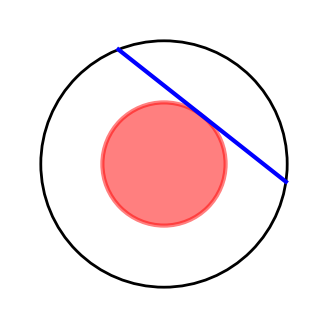

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axis
fig, ax = plt.subplots(figsize=(4, 4))

# 1. Geometry Constants
outer_radius = 2.0
inner_radius = 1.0  # Exactly half the radius

# 2. Draw the outer circle (black outline, solid line)
outer_circle = plt.Circle((0, 0), outer_radius, color='black', fill=False, linewidth=2, linestyle='solid')
ax.add_artist(outer_circle)

# 3. Draw the inner circle (0.5 alpha red fill, solid red outline)
# Use 'red' for the outline and an alpha value of 0.5 for the fill
inner_circle = plt.Circle((0, 0), inner_radius, facecolor='red', edgecolor='red', fill=True, alpha=0.5, linewidth=3, linestyle='solid')
ax.add_artist(inner_circle)

# 4. Generate the BLUE tangent line
# Define a random point on the inner red circle's boundary
angle = np.random.uniform(0, 2*np.pi)
tangent_point_inner = np.array([inner_radius * np.cos(angle), inner_radius * np.sin(angle)])

# The direction vector along the circle is perpendicular to the radius to that point.
# If radius vector is (x, y), the perpendicular direction vector is (-y, x).
line_direction = np.array([-tangent_point_inner[1], tangent_point_inner[0]])

# By Pythagorean theorem: d_midpoint_to_outer = sqrt(outer_r^2 - inner_r^2)
extension_length = np.sqrt(outer_radius**2 - inner_radius**2)

# Points where the tangent line intersects the outer circle boundary
intersection1 = tangent_point_inner - extension_length * (line_direction / np.linalg.norm(line_direction))
intersection2 = tangent_point_inner + extension_length * (line_direction / np.linalg.norm(line_direction))

# Draw the blue line between these intersection points
ax.plot([intersection1[0], intersection2[0]], [intersection1[1], intersection2[1]], color='blue', linewidth=3)

# 5. Final Plot Formatting
# Set axis limits, aspect ratio 'equal', and hide the axis lines
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
plt.axis('off')

plt.show()

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

### Answer :

Let $B$ represent a boy and $G$ represent a girl. Assuming birth order matters for defining the distinct combinations, there are four equally likely outcomes for a two-child family:

The sample space is

$$
\Omega=\{BB,BG,GB,GG\}
$$

The problem asks for a probability given that at least one of the children is a girl. This new information reduces our sample space.Because we know at least one child is a girl, the outcome $(B, B)$ is impossible. We can eliminate it from our list of possibilities.

Remaining outcomes are,

$$
\{BG,GB,GG\}
$$

We want to find the probability that both children are girls.

Looking at the restricted sample space of three possible outcomes, only one outcome represents the event where both children are girls: $(G, G)$.

Therefore, the probability is the number of successful outcomes divided by the total number of possible outcomes in the restricted sample space:

$$P(\text{Both Girls} \mid \text{At Least One Girl}) = \frac{1}{3}$$

So the answer is,

$$\boxed{\frac13}$$

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

### Answer :

### 1. The Probability Space $(\Omega,\mathfrak{F},P)$

The probability space consists of three components:
* **Sample Space ($\Omega$):** $\Omega=\{G_1, G_2, D_1, D_2\}$
* **$\sigma$-algebra ($\mathfrak{F}$):** Since $\mathfrak{F}=\mathfrak{P}(\Omega)$ (the power set), it contains all $2^4 = 16$ possible subsets of $\Omega$:
    $$
    \mathfrak{F} = \{\emptyset, \{G_1\}, \{G_2\}, \{D_1\}, \{D_2\}, \{G_1,G_2\}, \dots, \Omega\}
    $$
* **Probability Measure ($P$):** A function $P: \mathfrak{F} \to [0,1]$ defined by the additive sums of the elementary outcomes:
    $$
    P(\{G_1\})=0.50,\quad P(\{G_2\})=0.20,\quad P(\{D_1\})=0.10,\quad P(\{D_2\})=0.20
    $$

---

### 2. The $\sigma$-algebra Generated by $X$ ($\sigma(X)$)

The $\sigma$-algebra generated by a random variable is the collection of all pre-images of Borel sets. For a discrete variable, it is generated by the partition of the sample space induced by $X$.
* $X^{-1}(\{0\}) = \{G_1, G_2\}$
* $X^{-1}(\{1\}) = \{D_1, D_2\}$

Therefore, combining these with the empty set and the full sample space:
$$
\sigma(X) = \{\emptyset, \{G_1, G_2\}, \{D_1, D_2\}, \Omega\}
$$

---

### 3. The $\sigma$-algebra Generated by $Y$ ($\sigma(Y)$)

Similarly, $Y$ induces a partition of $\Omega$:
* $Y^{-1}(\{1\}) = \{G_1\}$
* $Y^{-1}(\{2\}) = \{G_2\}$
* $Y^{-1}(\{3\}) = \{D_1\}$
* $Y^{-1}(\{4\}) = \{D_2\}$

Because $Y$ perfectly isolates every single outcome in $\Omega$, the $\sigma$-algebra it generates is the full power set:
$$
\sigma(Y) = \mathfrak{P}(\Omega) = \mathfrak{F}
$$

---

### 4. Why $\sigma(X)\subseteq \sigma(Y)$ and Information Content

**Proof of subset:** Comparing the two collections of sets from Parts 2 and 3, it is immediately clear that every set in $\sigma(X)$ is also a set in $\mathfrak{P}(\Omega)$. Thus, $\sigma(X)\subseteq \sigma(Y)$.

**Explanation:** In measure theory, a $\sigma$-algebra represents the "information available" from observing a random variable. $Y$ contains more information because its mapping distinguishes the exact state of both *quality* and *machine origin*. $X$ only resolves the *quality*, mapping outcomes from Machine 1 and Machine 2 into indistinguishable lumps (e.g., both $G_1$ and $G_2$ evaluate to $X=0$). Since $Y$ provides a finer partition of reality, it contains strictly more information.

---

### 5. Marginal Distribution of $X$

We sum the probabilities of the events corresponding to each value of $X$:
* $$P(X=0) = P(\{G_1, G_2\}) = P(\{G_1\}) + P(\{G_2\}) = 0.50 + 0.20 = 0.70$$
* $$P(X=1) = P(\{D_1, D_2\}) = P(\{D_1\}) + P(\{D_2\}) = 0.10 + 0.20 = 0.30$$

---

### 6. Marginal Distribution of $Y$

The marginal distribution of $Y$ perfectly mirrors the underlying probabilities of the sample space:
* $$P(Y=1) = P(\{G_1\}) = 0.50$$
* $$P(Y=2) = P(\{G_2\}) = 0.20$$
* $$P(Y=3) = P(\{D_1\}) = 0.10$$
* $$P(Y=4) = P(\{D_2\}) = 0.20$$

---

### 7. Joint Probabilities

The joint probabilities track the intersection of the pre-images of $X$ and $Y$. Since $Y$ strictly determines $X$, most pairs are logically impossible (probability 0), but for the valid pairs requested:
* $$P(X=0,Y=1) = P(\{G_1, G_2\} \cap \{G_1\}) = P(\{G_1\}) = 0.50$$
* $$P(X=0,Y=2) = P(\{G_1, G_2\} \cap \{G_2\}) = P(\{G_2\}) = 0.20$$
* $$P(X=1,Y=3) = P(\{D_1, D_2\} \cap \{D_1\}) = P(\{D_1\}) = 0.10$$
* $$P(X=1,Y=4) = P(\{D_1, D_2\} \cap \{D_2\}) = P(\{D_2\}) = 0.20$$

---

### 8. Conditional Probabilities

Using Bayes' theorem and the definition of conditional probability ($P(A \mid B) = P(A \cap B) / P(B)$):
* $$P(X=1\mid Y=3) = \frac{P(X=1, Y=3)}{P(Y=3)} = \frac{0.10}{0.10} = 1$$
* $$P(X=1\mid Y=4) = \frac{P(X=1, Y=4)}{P(Y=4)} = \frac{0.20}{0.20} = 1$$
* $$P(Y=3\mid X=1) = \frac{P(X=1, Y=3)}{P(X=1)} = \frac{0.10}{0.30} = \frac{1}{3} \approx 0.333$$
* $$P(Y=4\mid X=1) = \frac{P(X=1, Y=4)}{P(X=1)} = \frac{0.20}{0.30} = \frac{2}{3} \approx 0.667$$

---

### 9. Interpreting the Difference in Conditioning

* **Conditioning on $Y$:** When you condition on $Y$, you have complete information about the outcome (both machine and quality). Therefore, there is zero uncertainty left about $X$. The probabilities of $X$ become deterministic ($1$ or $0$).
* **Conditioning on $X$:** When you condition on $X$ (e.g., knowing an item is defective, $X=1$), you still face uncertainty about *which* machine produced it. This is reflected in the non-deterministic fractional probabilities (1/3 and 2/3).

---

### 10. Information Asymmetry Between $\sigma(X)$ and $\sigma(Y)$

* **Information in $\sigma(X)$ but not in $\sigma(Y)$:** **None.** Because $\sigma(X) \subseteq \sigma(Y)$, everything knowable from observing $X$ is already perfectly knowable from observing $Y$.
* **Information in $\sigma(Y)$ but not in $\sigma(X)$:** **The machine of origin.** $\sigma(Y)$ tells you whether Machine 1 or Machine 2 produced the item, allowing you to distinguish between subsets like $\{G_1\}$ and $\{G_2\}$. $\sigma(X)$ remains entirely blind to this distinction.

---

### 11. Python-based Visualization


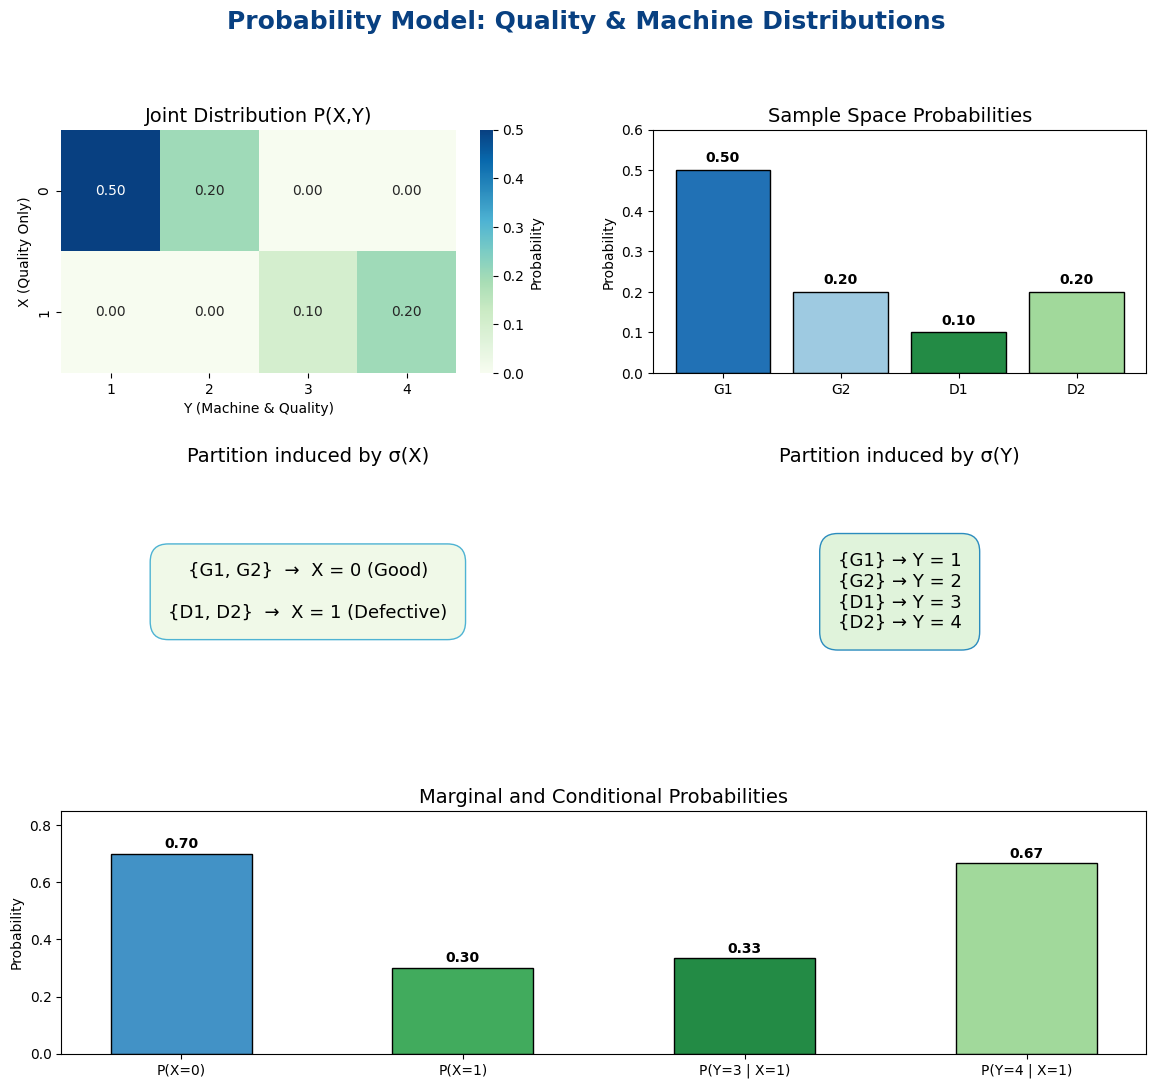

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# 1. Data Setup
# ==========================================
omega = ["G1", "G2", "D1", "D2"]
p = np.array([0.50, 0.20, 0.10, 0.20])

# Marginals and Conditionals
px = {0: p[0] + p[1], 1: p[2] + p[3]}
p_y3_given_x1 = p[2] / px[1]
p_y4_given_x1 = p[3] / px[1]

# Joint distribution table for (X,Y)
joint = np.array([
    [0.50, 0.20, 0.00, 0.00],  # X = 0
    [0.00, 0.00, 0.10, 0.20]   # X = 1
])

# ==========================================
# 2. Semantic Blue-Green Color Palette
# ==========================================
# Blue shades for "Good" (G), Green shades for "Defective" (D)
color_g1 = "#2171b5"  # Dark Blue
color_g2 = "#9ecae1"  # Light Blue
color_d1 = "#238b45"  # Dark Green
color_d2 = "#a1d99b"  # Light Green

# Aggregate colors for X marginals
color_x0 = "#4292c6"  # Medium Blue
color_x1 = "#41ab5d"  # Medium Green

# ==========================================
# 3. Layout & Figure Setup
# ==========================================
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.2)

fig.suptitle("Probability Model: Quality & Machine Distributions", fontsize=18, fontweight='bold', color="#084081")

# Assign subplots to the grid
ax_heat   = fig.add_subplot(gs[0, 0])   # Top Left
ax_sample = fig.add_subplot(gs[0, 1])   # Top Right
ax_part_x = fig.add_subplot(gs[1, 0])   # Middle Left
ax_part_y = fig.add_subplot(gs[1, 1])   # Middle Right
ax_marg   = fig.add_subplot(gs[2, :])   # Bottom Row (spans both columns)

# ==========================================
# 4. Plotting
# ==========================================

# --- Top Left: Heatmap ---
# Using 'GnBu' (Green-Blue) colormap to match the theme
sns.heatmap(
    joint, annot=True, cmap="GnBu", fmt=".2f",
    xticklabels=[1, 2, 3, 4], yticklabels=[0, 1],
    cbar_kws={'label': 'Probability'}, ax=ax_heat
)
ax_heat.set_xlabel("Y (Machine & Quality)")
ax_heat.set_ylabel("X (Quality Only)")
ax_heat.set_title("Joint Distribution P(X,Y)", fontsize=14)

# --- Top Right: Sample Space ---
ax_sample.bar(omega, p, color=[color_g1, color_g2, color_d1, color_d2], edgecolor="black")
ax_sample.set_title("Sample Space Probabilities", fontsize=14)
ax_sample.set_ylabel("Probability")
ax_sample.set_ylim(0, 0.6)
for i, val in enumerate(p):
    ax_sample.text(i, val + 0.02, f"{val:.2f}", ha="center", fontweight='bold')

# --- Middle Left: Partition X ---
ax_part_x.axis("off")
ax_part_x.set_title("Partition induced by σ(X)", fontsize=14)
ax_part_x.text(
    0.5, 0.5,
    "{G1, G2}  →  X = 0 (Good)\n\n{D1, D2}  →  X = 1 (Defective)",
    fontsize=13, ha="center", va="center",
    bbox=dict(facecolor="#f0f9e8", edgecolor="#4eb3d3", pad=20, boxstyle="round,pad=1")
)

# --- Middle Right: Partition Y ---
ax_part_y.axis("off")
ax_part_y.set_title("Partition induced by σ(Y)", fontsize=14)
ax_part_y.text(
    0.5, 0.5,
    "{G1} → Y = 1\n{G2} → Y = 2\n{D1} → Y = 3\n{D2} → Y = 4",
    fontsize=13, ha="center", va="center",
    bbox=dict(facecolor="#e0f3db", edgecolor="#2b8cbe", pad=20, boxstyle="round,pad=1")
)

# --- Bottom Row: Marginals & Conditionals ---
x_labels = ["P(X=0)", "P(X=1)", "P(Y=3 | X=1)", "P(Y=4 | X=1)"]
x_vals = [px[0], px[1], p_y3_given_x1, p_y4_given_x1]

# Colors explicitly match the logic above
bottom_colors = [color_x0, color_x1, color_d1, color_d2]

bars = ax_marg.bar(x_labels, x_vals, color=bottom_colors, edgecolor="black", width=0.5)
ax_marg.set_title("Marginal and Conditional Probabilities", fontsize=14)
ax_marg.set_ylabel("Probability")
ax_marg.set_ylim(0, 0.85)
for i, val in enumerate(x_vals):
    ax_marg.text(i, val + 0.02, f"{val:.2f}", ha="center", fontweight='bold')

plt.show()

### 12. Shannon Entropy (using natural logarithms)

Using natural logarithms, the Shannon entropy is defined as:
$$H(Z)=-\sum_{z}P(z)\ln P(z)$$

**1. Marginal Entropy of $X$, $H(X)$:**
$$H(X)=-(0.70\ln 0.70+0.30\ln 0.30)$$
$$H(X)\approx 0.61086$$

**2. Marginal Entropy of $Y$, $H(Y)$:**
$$H(Y)=-(0.50\ln 0.50+0.20\ln 0.20+0.10\ln 0.10+0.20\ln 0.20)$$
$$H(Y)\approx 1.22061$$

**3. Joint Entropy, $H(X,Y)$:**
For the joint entropy, we sum over all pairs:
$$H(X,Y)=-\sum_{x,y}P(x,y)\ln P(x,y)$$
Since only the nonzero terms contribute, this mirrors the calculation for $Y$:
$$H(X,Y)=-(0.50\ln 0.50+0.20\ln 0.20+0.10\ln 0.10+0.20\ln 0.20)$$
$$H(X,Y)\approx 1.22061$$

**4. Conditional Entropy, $H(X\mid Y)$:**
Because each value of $Y$ determines $X$ exactly, there is no remaining uncertainty:
$$H(X\mid Y)=0$$

**5. Conditional Entropy, $H(Y\mid X)$:**
Using the chain rule for entropy $H(Y\mid X)=H(X,Y)-H(X)$:
$$H(Y\mid X)\approx 1.22061-0.61086$$
$$H(Y\mid X)\approx 0.60975$$

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subset \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


### Answer :

### 1. The Probability Space

The probability space is:
$$
\Omega=\mathbb{R}^2, \qquad \mathfrak{F}=\mathfrak{B}(\mathbb{R}^2),
$$
where $\mathfrak{B}(\mathbb{R}^2)$ is the Borel $\sigma$-algebra on $\mathbb{R}^2$.

A point $\omega\in\Omega$ has the form:
$$
\omega=(t,p),
$$
where $t$ is the standardized temperature deviation and $p$ is the standardized pressure deviation.

The probability measure $P$ is defined by the joint density:
$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb{R}^2.
$$
Thus, for any Borel set $A\subseteq\mathbb{R}^2$:
$$
P(A)=\iint_A f_{T,P}(t,p)\,dt\,dp.
$$
Since $T\sim N(0,1)$ and $P\sim N(0,4)$ are independent, this constitutes a valid probability measure.

---

### 2. The $\sigma$-algebra Generated by $X$

The random variable $X$ is defined by:
$$
X(t,p)=t.
$$
Thus, $X$ records only the temperature deviation. The $\sigma$-algebra generated by $X$ is:
$$
\sigma(X)=\left\{X^{-1}(B): B\in\mathfrak{B}(\mathbb{R})\right\}.
$$
Since the pre-image is:
$$
X^{-1}(B)=\{(t,p)\in\mathbb{R}^2:t\in B\}=B\times \mathbb{R},
$$
we obtain:
$$
\sigma(X)=\{B\times\mathbb{R}: B\in\mathfrak{B}(\mathbb{R})\}.
$$
So, $\sigma(X)$ consists exactly of all sets (vertical strips in the plane) that depend only on the temperature coordinate.

---

### 3. The $\sigma$-algebra Generated by $Y$

The random variable $Y$ is defined by:
$$
Y(t,p)=(t,p).
$$
Thus, $Y$ records both temperature and pressure. Since $Y$ is the identity map on $\mathbb{R}^2$, its generated $\sigma$-algebra is:
$$
\sigma(Y)=\mathfrak{B}(\mathbb{R}^2).
$$
Indeed, for every Borel set $A\subseteq\mathbb{R}^2$:
$$
Y^{-1}(A)=A.
$$
Hence, $\sigma(Y)=\mathfrak{B}(\mathbb{R}^2)$.

---

### 4. Comparing Information Content

Since every set of the form $B\times\mathbb{R}$ is a Borel subset of $\mathbb{R}^2$, we have:
$$
\sigma(X)\subset \sigma(Y).
$$
The inclusion is strict because sets such as $[-1,1]\times[-2,2]$ belong to $\sigma(Y)$ but not to $\sigma(X)$, since they depend on both coordinates.

**Conclusion:** $Y$ contains strictly more information than $X$. Knowing $X$ tells us only the temperature deviation, while knowing $Y$ tells us both temperature and pressure deviations.

---

### 5. Marginal Density of $X$

The marginal density of $X$ is obtained by integrating out $p$:
$$
f_X(x)=\int_{-\infty}^{\infty} f_{T,P}(x,p)\,dp.
$$
Substituting the joint density:
$$
f_X(x)=\int_{-\infty}^{\infty}\frac{1}{4\pi}\exp\left(-\frac{x^2}{2}-\frac{p^2}{8}\right)\,dp.
$$
Since a normal density integrates to 1:
$$
\int_{-\infty}^{\infty}\frac{1}{\sqrt{8\pi}}\exp\left(-\frac{p^2}{8}\right)\,dp=1,
$$
this simplifies to:
$$
f_X(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right).
$$
Thus, $X\sim N(0,1)$.

---

### 6. Marginal Density of $Y$

The marginal density of $Y$ is simply its joint density, since $Y=(T,P)$:
$$
f_Y(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right).
$$
Thus, $Y$ is a bivariate normal random vector with independent components.

---

### 7. Probability Computations

First, by symmetry of the standard normal distribution:
$$
P(X\leq 0)=P(T\leq 0)=\frac{1}{2}.
$$
Next, using the standard normal cumulative distribution function $\Phi$:
$$
P(X>1)=P(T>1)=1-\Phi(1) \approx 0.1587.
$$
For the half-plane event:
$$
P\bigl(Y\in (-\infty,0]\times\mathbb{R}\bigr)=P(T\leq 0)=\frac{1}{2}.
$$
Finally, for the rectangular region:
$$
P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=P(-1\leq T\leq 1,\ -2\leq P\leq 2).
$$
Since $T$ and $P$ are independent:
$$
P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=P(-1\leq T\leq 1)\,P(-2\leq P\leq 2).
$$
Given $T\sim N(0,1)$ and $P\sim N(0,4)$ (which means $P/2\sim N(0,1)$):
$$
P(-1\leq T\leq 1) = 2\Phi(1)-1
$$
$$
P(-2\leq P\leq 2) = P(-1\leq P/2\leq 1) = 2\Phi(1)-1
$$
Therefore:
$$
P\bigl(Y\in[-1,1]\times[-2,2]\bigr)=\bigl(2\Phi(1)-1\bigr)^2.
$$
Numerically, $2\Phi(1)-1\approx 0.6827$, so:
$$
P\bigl(Y\in[-1,1]\times[-2,2]\bigr)\approx 0.466.
$$

---

### 8. Conditional Distribution of $X$ given $Y$

Since $Y=(T,P)$ completely determines $T$, the conditional distribution of $X$ given $Y=(t,p)$ is degenerate at $t$:
$$
P(X=t\mid Y=(t,p))=1.
$$
Equivalently, the conditional law of $X$ given $Y=(t,p)$ is $\delta_t$, the Dirac mass at $t$. This means that once both temperature and pressure are known, the temperature is known exactly.

---

### 9. Conditional Distribution of $Y$ given $X$

The conditional distribution of $Y$ given $X=t$ is the distribution of the random vector $(t, P)$ where $P \sim N(0,4)$. Thus:
$$
Y \mid X=t \sim (t, P).
$$
Since $T$ and $P$ are independent, the conditional probability measure $P_{Y|X=t}$ is the product measure $\delta_t \otimes \mathscr{N}(0,4)$.
The conditional density $f_{Y|X}((u, v) \mid t)$ is the Radon-Nikodym derivative expressed as:
$$
f_{Y|X}\bigl((u,v)\mid t\bigr) = \delta_t(u) \cdot \frac{1}{\sqrt{8\pi}} \exp\left(-\frac{v^2}{8}\right).
$$

*Informally:* Given $X=t$, the temperature component is fixed at $t$ (Dirac mass), while the pressure component remains normally distributed with its original variance.

---

### 10. Information Gained by Conditioning

* **Conditioning on $X$:** We know only the temperature deviation. There is still uncertainty about the pressure deviation (it remains random).
* **Conditioning on $Y$:** We know both temperature and pressure. Both coordinates are known exactly. Thus, conditioning on $Y$ provides strictly more information.

---

### 11. Measurability and Projections

Define the projection map $\pi_1:\mathbb{R}^2\to\mathbb{R}$ by:
$$
\pi_1(t,p)=t.
$$
Then:
$$
X=\pi_1\circ Y,
$$
because $(\pi_1\circ Y)(t,p)=\pi_1(t,p)=t=X(t,p)$.
Since $\pi_1$ is Borel measurable and $X$ is a composition resulting in a measurable function of $Y$, it naturally follows that:
$$
\sigma(X)\subseteq \sigma(Y).
$$
This gives a direct, measure-theoretic explanation for why $Y$ is more informative than $X$.

---

### 12. Python-based Visualization

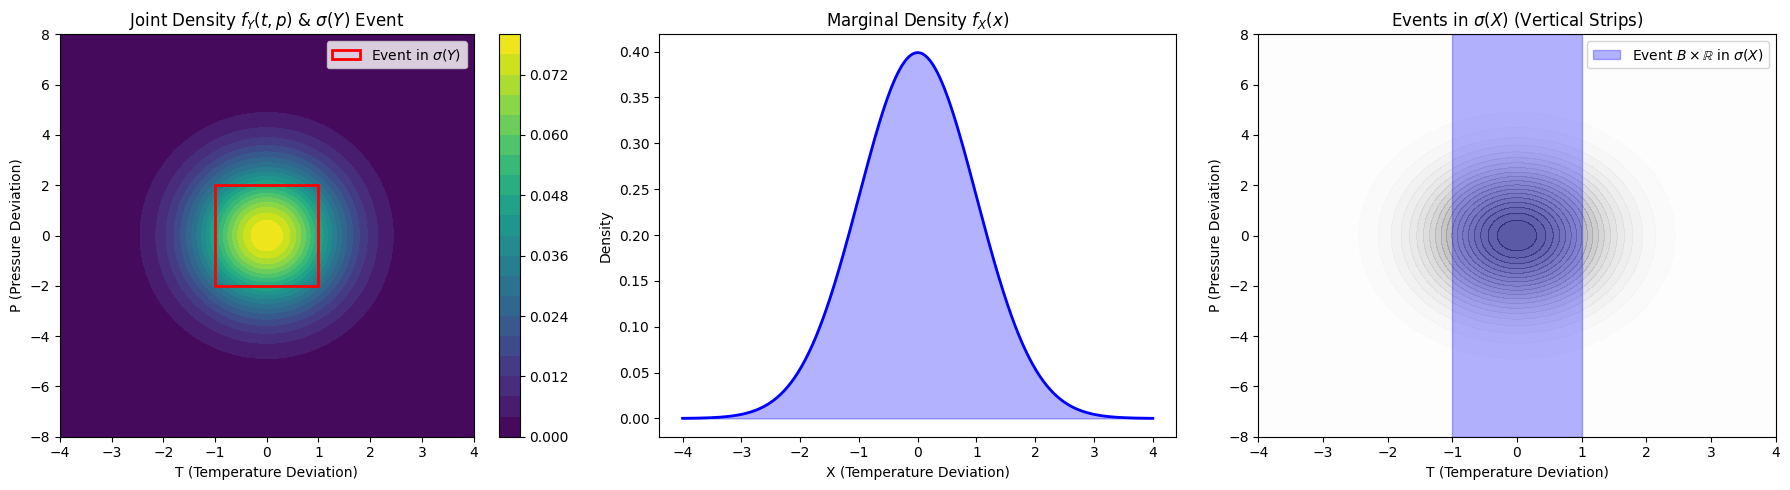

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Setup Grid
t = np.linspace(-4, 4, 400)
p = np.linspace(-8, 8, 400)
T, P = np.meshgrid(t, p)

# 2. Joint density f_Y(t,p)
Z = (1 / (4 * np.pi)) * np.exp(-(T**2) / 2 - (P**2) / 8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Joint Density & Sigma(Y) Event
contour = axes[0].contourf(T, P, Z, levels=20, cmap='viridis')
# Added 'r' prefix for raw string
axes[0].set_title(r'Joint Density $f_Y(t,p)$ & $\sigma(Y)$ Event')
axes[0].set_xlabel('T (Temperature Deviation)')
axes[0].set_ylabel('P (Pressure Deviation)')
fig.colorbar(contour, ax=axes[0])

# Rectangle showing an event that only sigma(Y) can isolate
# Added 'r' prefix for raw string
rect = plt.Rectangle((-1, -2), 2, 4, edgecolor='red', facecolor='none', lw=2, label=r'Event in $\sigma(Y)$')
axes[0].add_patch(rect)
axes[0].legend(loc="upper right")

# Plot B: Marginal Density f_X(x)
f_X = norm.pdf(t, 0, 1)
axes[1].plot(t, f_X, color='blue', lw=2)
axes[1].fill_between(t, f_X, alpha=0.3, color='blue')
axes[1].set_title(r'Marginal Density $f_X(x)$')
axes[1].set_xlabel('X (Temperature Deviation)')
axes[1].set_ylabel('Density')

# Plot C: Sigma(X) Event (Vertical Strips)
axes[2].contourf(T, P, Z, levels=20, cmap='Greys', alpha=0.5)
# Added 'r' prefix for raw string
axes[2].set_title(r'Events in $\sigma(X)$ (Vertical Strips)')
axes[2].set_xlabel('T (Temperature Deviation)')
axes[2].set_ylabel('P (Pressure Deviation)')

# Vertical strip showing an event in sigma(X)
# Added 'r' prefix and cleaned up the times command
axes[2].axvspan(-1, 1, color='blue', alpha=0.3, label=r'Event $B \times \mathbb{R}$ in $\sigma(X)$')
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 13. Differential Entropy of $X$

Since $X\sim N(0,1)$, its differential entropy is:
$$
h(X)=\frac{1}{2}\ln(2\pi e).
$$
Numerically:
$$
h(X)\approx 1.4189 \text{ nats}.
$$

---

### 14. Differential Entropy of $Y$

Since $Y=(T,P)$ has independent normal components with variances $1$ and $4$, its differential entropy is additive:
$$
h(Y)=h(T)+h(P).
$$
Where $h(T)=\frac{1}{2}\ln(2\pi e)$ and $h(P)=\frac{1}{2}\ln(2\pi e\cdot 4)$.
Therefore:
$$
h(Y)=\frac{1}{2}\ln(2\pi e)+\frac{1}{2}\ln(8\pi e) = \frac{1}{2}\ln\bigl((2\pi e)^2\cdot 4\bigr) = \ln(2\pi e)+\ln 2.
$$
Numerically:
$$
h(Y)\approx 3.5310 \text{ nats}.
$$

---

### 15. Conditional Differential Entropy $h(Y \mid X)$

Since $T$ and $P$ are independent and $Y=(T,P)$, the uncertainty remaining in $Y$ after $X=T$ is observed is exactly the uncertainty in $P$. Thus:
$$
h(Y\mid X)=h(P)=\frac{1}{2}\ln(2\pi e\cdot 4) = \frac{1}{2}\ln(8\pi e).
$$
Numerically:
$$
h(Y\mid X)\approx 2.1121 \text{ nats}.
$$
**Physical Interpretation:** Once the temperature deviation is known, the only remaining uncertainty in the system is the pressure deviation.

---

### 16. The Behavior of $h(X \mid Y)$

Since $X$ is a deterministic function of $Y$, one might expect that $h(X\mid Y)=0$. However, for differential entropy, this is incorrect.

In the continuous setting, the conditional law of $X$ given $Y$ is degenerate (a Dirac delta), so the conditional differential entropy is not an ordinary finite quantity. It is best understood as formally tending to:
$$
-\infty.
$$
This highlights a major difference between discrete entropy and differential entropy:
* **Discrete case:** If $X$ is determined by $Y$, then $H(X\mid Y)=0$.
* **Continuous case:** Exact deterministic dependence corresponds to a singular continuous distribution, driving the differential entropy to $-\infty$.

**Conclusion:**
The variables $X$ and $Y$ exist on the same space, but $X$ is a coarser observation. This is mathematically rigorous through $\sigma(X)\subseteq \sigma(Y)$ and physically intuitive through entropy calculations: knowing $X$ leaves uncertainty about $Y$, but knowing $Y$ completely collapses the uncertainty of $X$.